In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

FILE = "data.xlsx"   # adjust path if needed
df = pd.read_excel(FILE, sheet_name=0)

print("Columns found:", list(df.columns))
print("\nFirst 8 rows:")
print(df.head(8))
print("\nDtypes:")
print(df.dtypes)

Columns found: ['Unnamed: 0', 'Whatsapp', 'Instagram', 'Youtube', 'Games', 'Others', 'Total']

First 8 rows:
  Unnamed: 0  Whatsapp Instagram   Youtube     Games    Others     Total
0 2025-09-01  01:33:00  01:29:00  00:30:00  01:43:00  00:22:00  05:37:00
1 2025-09-02  02:05:00  01:35:00  01:24:00  00:33:00  00:25:00  06:02:00
2 2025-09-03  02:37:00  01:09:00  02:55:00  00:12:00  00:03:00  06:56:00
3 2025-09-04  01:50:00  01:21:00  01:36:00  01:35:00  00:57:00  07:19:00
4 2025-09-05  01:37:00  01:35:00  00:20:00  01:08:00  00:30:00  05:10:00
5 2025-09-06  00:59:00  02:59:00  00:13:00  00:53:00  00:28:00  05:32:00
6 2025-09-07  02:34:00  01:36:00  01:03:00  01:35:00  00:14:00  07:02:00
7 2025-09-08  02:52:00  02:22:00  01:38:00  00:34:00  00:32:00  07:58:00

Dtypes:
Unnamed: 0    datetime64[ns]
Whatsapp              object
Instagram             object
Youtube               object
Games                 object
Others                object
Total                 object
dtype: object


In [5]:
# --- 1) Find/parse the date column, and create a canonical df['date'] ---
candidates = [c for c in df.columns if str(c).lower() == "date"] + \
             [c for c in df.columns if "unnamed" in str(c).lower()] + \
             list(df.columns)

date_col = None
for c in candidates:
    if df[c].notna().sum() > 0:
        date_col = c
        break

print("\nChosen date column candidate:", date_col)

df['date'] = pd.to_datetime(df[date_col], errors='coerce')
print("After parsing, 'date' NaT count:", df['date'].isna().sum(), "/", len(df))

if df['date'].isna().all():
    df['date'] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    print("After second parse (dayfirst), 'date' NaT count:", df['date'].isna().sum(), "/", len(df))

if df['date'].isna().all():
    print("WARNING: Could not parse any real dates. Creating integer index-based dates instead.")
    df['date'] = pd.date_range(start="2000-01-01", periods=len(df), freq='D')

# ensure date is sorted for plotting
df = df.sort_values('date').reset_index(drop=True)


Chosen date column candidate: Unnamed: 0
After parsing, 'date' NaT count: 0 / 26


In [6]:
# --- 2) Determine app columns (everything except the original date col and df['date']) ---
original_date_col = date_col
app_cols = [c for c in df.columns if c not in [original_date_col, 'date']]

possible_exclude = ['Total', 'total', 'Unnamed: 0.1']
app_cols = [c for c in app_cols if c not in possible_exclude]
print("\nApp columns to process:", app_cols)



App columns to process: ['Whatsapp', 'Instagram', 'Youtube', 'Games', 'Others']


In [7]:
# --- 3) Cleaning function to convert many formats to minutes ---
def clean_to_minutes(series):
    out = []
    for v in series:
        if pd.isna(v):
            out.append(np.nan)
            continue
        s = str(v).strip()
        s_nocomma = s.replace(',', '')
        # HH:MM:SS or HH:MM (assume HH:MM) or MM:SS ambiguous -> assume HH:MM likely for screen time
        if ":" in s:
            parts = s.split(":")
            try:
                parts = [float(p) for p in parts]
                if len(parts) == 3:
                    # hours:minutes:seconds -> convert to minutes
                    mins = parts[0] * 60 + parts[1] + parts[2] / 60.0
                elif len(parts) == 2:
                    # assume hours:minutes -> total minutes
                    mins = parts[0] * 60 + parts[1]
                else:
                    mins = parts[0]
                out.append(mins)
                continue
            except Exception:
                pass
        # If contains words like 'hour', 'hr'
        if re.search(r"hr|hour", s.lower()):
            num_search = re.search(r"[-]?\d+(\.\d+)?", s_nocomma)
            if num_search:
                hours = float(num_search.group(0))
                out.append(hours * 60)
                continue
        # If contains 'min'
        if re.search(r"min", s.lower()):
            num_search = re.search(r"[-]?\d+(\.\d+)?", s_nocomma)
            if num_search:
                out.append(float(num_search.group(0)))
                continue
        # Try numeric extraction (plain numbers assumed minutes)
        num_search = re.search(r"[-]?\d+(\.\d+)?", s_nocomma)
        if num_search:
            out.append(float(num_search.group(0)))
            continue
        # fallback
        out.append(np.nan)
    return pd.Series(out)

# Apply cleaning for each app column, create new column e.g., 'Whatsapp_mins'
mins_cols = []
for c in app_cols:
    newc = f"{c}_mins"
    df[newc] = clean_to_minutes(df[c])
    mins_cols.append(newc)
    print(f"{newc}: non-null count = {df[newc].notna().sum()}, sum = {df[newc].sum(skipna=True)}")

Whatsapp_mins: non-null count = 26, sum = 2892.0
Instagram_mins: non-null count = 26, sum = 2799.0
Youtube_mins: non-null count = 26, sum = 1726.0
Games_mins: non-null count = 26, sum = 1317.0
Others_mins: non-null count = 26, sum = 1621.0


In [8]:
# --- 4) Create tidy long dataframe and drop rows with NaN minutes ---
df_long = df[['date'] + mins_cols].melt(id_vars=['date'], value_vars=mins_cols,
                                        var_name='app_col', value_name='minutes')
df_long['app'] = df_long['app_col'].str.replace('_mins', '', regex=False)
df_long = df_long[['date', 'app', 'minutes']].dropna(subset=['minutes']).reset_index(drop=True)
print("\nTidy (long) rows after dropping NaNs:", len(df_long))
print(df_long.head(12))


Tidy (long) rows after dropping NaNs: 130
         date       app  minutes
0  2025-09-01  Whatsapp     93.0
1  2025-09-02  Whatsapp    125.0
2  2025-09-03  Whatsapp    157.0
3  2025-09-04  Whatsapp    110.0
4  2025-09-05  Whatsapp     97.0
5  2025-09-06  Whatsapp     59.0
6  2025-09-07  Whatsapp    154.0
7  2025-09-08  Whatsapp    172.0
8  2025-09-09  Whatsapp     89.0
9  2025-09-10  Whatsapp     50.0
10 2025-09-11  Whatsapp     55.0
11 2025-09-12  Whatsapp     39.0


In [9]:
# --- 5) Pivot for plotting and sanity checks ---
pivot = df_long.pivot_table(index='date', columns='app', values='minutes', aggfunc='sum').sort_index()
print("\nPivot shape:", pivot.shape)
print("Pivot (head):")
print(pivot.head())


Pivot shape: (26, 5)
Pivot (head):
app         Games  Instagram  Others  Whatsapp  Youtube
date                                                   
2025-09-01  103.0       89.0    22.0      93.0     30.0
2025-09-02   33.0       95.0    25.0     125.0     84.0
2025-09-03   12.0       69.0     3.0     157.0    175.0
2025-09-04   95.0       81.0    57.0     110.0     96.0
2025-09-05   68.0       95.0    30.0      97.0     20.0


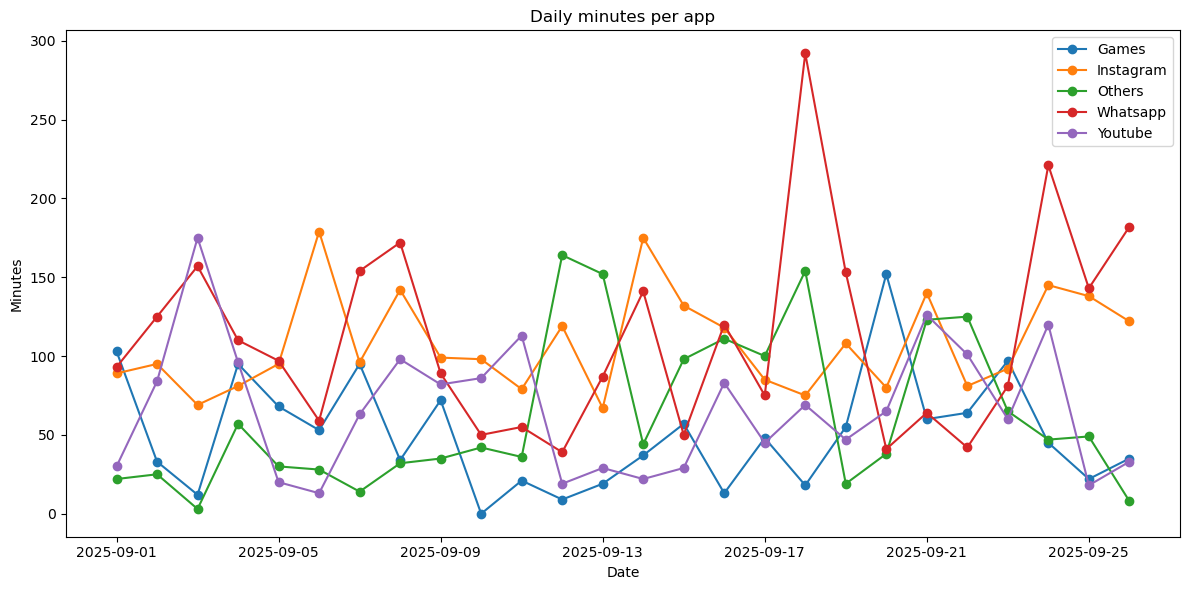

In [10]:
# Check if data exists
if pivot.empty or pivot.sum().sum() == 0:
    print("\nWARNING: After cleaning, there are no numeric minutes to plot (all zeros or missing).")
else:
    # 1) Line plot per app
    plt.figure(figsize=(12, 6))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker='o', label=col)
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Minutes")
    plt.title("Daily minutes per app")
    plt.tight_layout()
    plt.show()

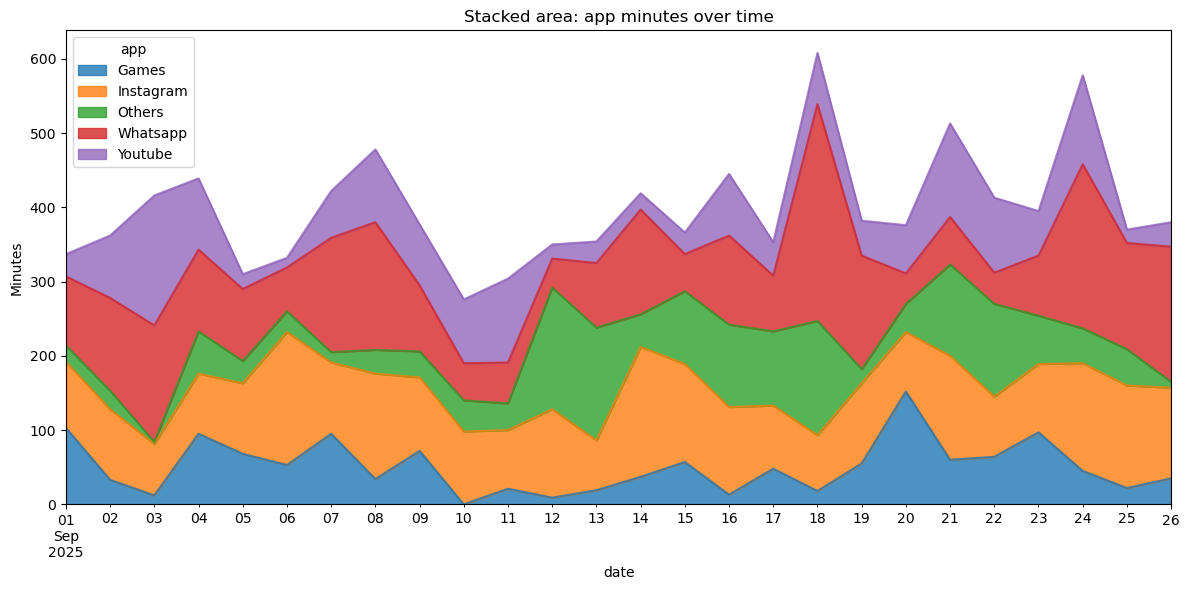

In [11]:

    # 2) Stacked area
    plt.figure(figsize=(12, 6))
    pivot.fillna(0).plot.area(ax=plt.gca(), alpha=0.8)
    plt.ylabel("Minutes")
    plt.title("Stacked area: app minutes over time")
    plt.tight_layout()
    plt.show()


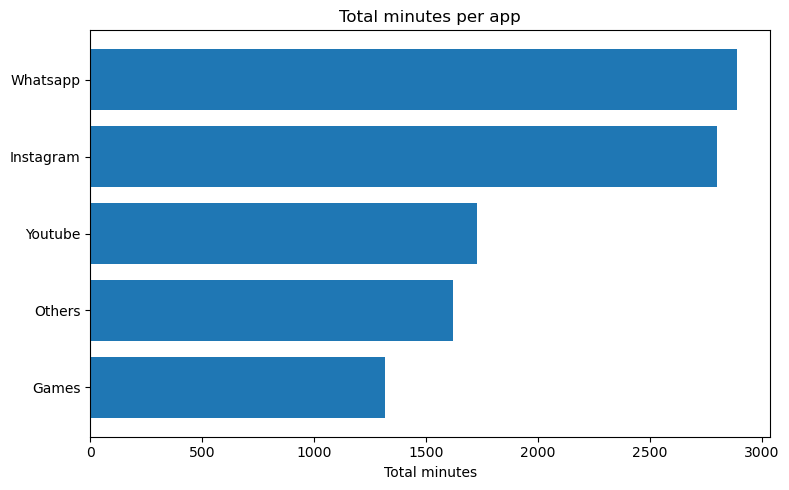

In [13]:
    # 3) Totals per app
    totals = pivot.sum().sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    plt.barh(totals.index[::-1], totals.values[::-1])
    plt.xlabel("Total minutes")
    plt.title("Total minutes per app")
    plt.tight_layout()
    plt.show()

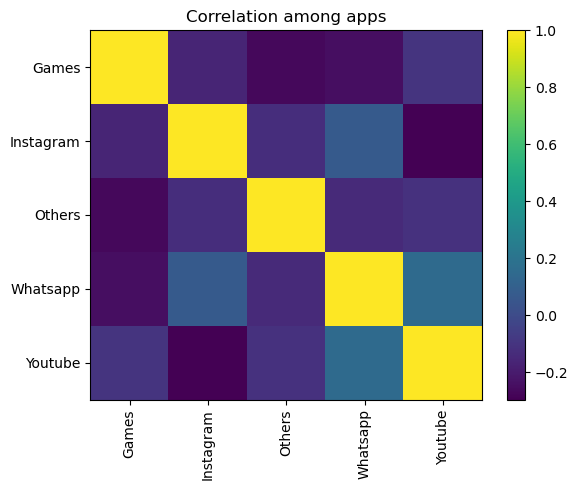

In [14]:
    # 4) Correlation heatmap
    corr = pivot.corr()
    plt.figure(figsize=(6, 5))
    plt.imshow(corr, interpolation='nearest', aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation among apps")
    plt.tight_layout()
    plt.show()

In [16]:
# Save tidy long file
df_long.to_csv("usage_long.csv", index=False, encoding="utf-8")
df_long.to_excel("usage_long.xlsx", index=False)
print("Saved usage_long.csv and usage_long.xlsx")

Saved usage_long.csv and usage_long.xlsx
